# Day 4 — Loading Open Models with Hugging Face

Learn how to load GPT-2 and instruction-tuned models, experiment with temperature, and visualize results.

In [1]:
!pip install transformers matplotlib --quiet

## 1. Import Libraries

In [2]:
from transformers import pipeline
import matplotlib.pyplot as plt

c:\Users\Nemochan\Desktop\ai-engineering-journey\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Base Model: GPT-2 with Different Temperatures

In [3]:
print("Using GPT-2 (Base Model)\n")

prompt = "My firewall keeps blocking"
generator = pipeline("text-generation", model="gpt2")

temperatures = [0.3, 0.7, 1.2]
generated_texts = []

for temp in temperatures:
    result = generator(
        prompt,
        max_new_tokens=40,
        temperature=temp,
        do_sample=True,
        pad_token_id=50256
    )
    text = result[0]["generated_text"]
    generated_texts.append(text)

    print(f"Temperature = {temp}")
    print(text)
    print("-" * 80)

Using GPT-2 (Base Model)



Loading weights: 100%|██████████| 148/148 [00:00<00:00, 5210.01it/s]
[transformers] Passing `generation_config` together with generation-related arguments=({'temperature', 'pad_token_id', 'do_sample', 'max_new_tokens'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
[transformers] Both `max_new_tokens` (=40) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer GPT2Tokenizer. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_thoug

Temperature = 0.3
My firewall keeps blocking the Internet. It's a simple matter of setting up a firewall on your computer.

If you're using Windows 7, you can use the following commands to get the firewall working.


--------------------------------------------------------------------------------


[transformers] Both `max_new_tokens` (=40) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Temperature = 0.7
My firewall keeps blocking traffic to these networks. But, if you have a firewall that's not blocked, we can use that to block certain Internet traffic, and you can also use that to disable your firewall. And we
--------------------------------------------------------------------------------
Temperature = 1.2
My firewall keeps blocking people who are here via a VPN so only usernames, passwords and some sensitive data are available to them.

It seems this was just that: a bug in our system. The next
--------------------------------------------------------------------------------


## 3. Instruction-Tuned Model

In [4]:
print("\nUsing Instruction-Tuned Model (Qwen2.5-0.5B-Instruct)\n")

chat = pipeline("text-generation", model="Qwen/Qwen2.5-0.5B-Instruct")

messages = [
    {"role": "user", "content": "Why does a firewall sometimes block legitimate traffic?"}
]

response = chat(messages, max_new_tokens=120, temperature=0.7)

print("Question:", messages[0]["content"])
print("\nAnswer:")
print(response[0]["generated_text"][-1]["content"])


Using Instruction-Tuned Model (Qwen2.5-0.5B-Instruct)



Loading weights: 100%|██████████| 290/290 [00:00<00:00, 2303.80it/s]
[transformers] Passing `generation_config` together with generation-related arguments=({'temperature', 'max_new_tokens'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
[transformers] Both `max_new_tokens` (=120) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer Qwen2Tokenizer. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=Tr

Question: Why does a firewall sometimes block legitimate traffic?

Answer:
A firewall's primary function is to filter and control incoming and outgoing network traffic based on predefined rules and policies. It aims to protect the network from unauthorized access or malicious activities.

When a firewall blocks legitimate traffic, it could be due to several reasons:

1. **Policy Violation**: The firewall might have inadvertently blocked legitimate traffic because its policy was not properly configured or applied in certain scenarios. For example, if the firewall has been set up to allow only specific types of traffic (e.g., web browsing), but an application that requires authentication fails to pass through this layer, the firewall may block that


## 4. Visualization: Effect of Temperature

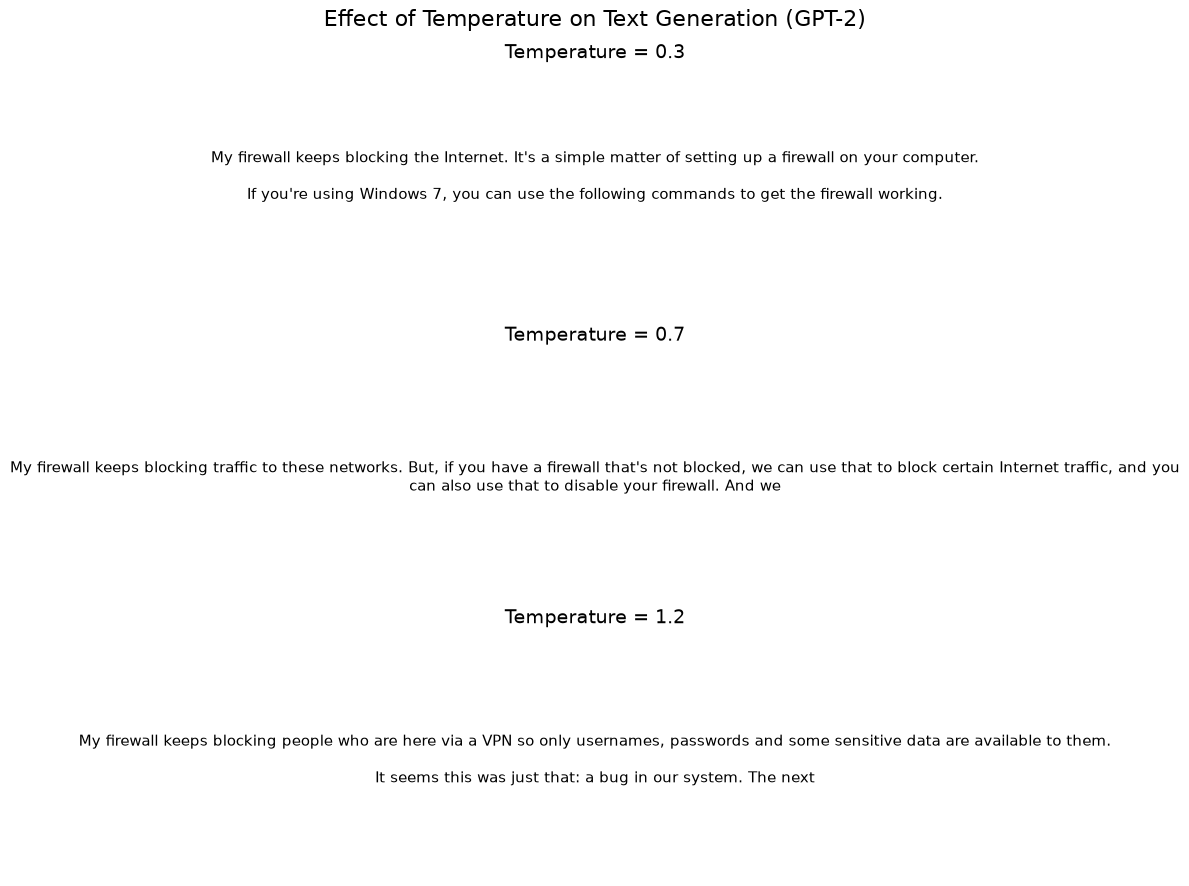

In [5]:
plt.figure(figsize=(12, 9))

for i, temp in enumerate(temperatures):
    plt.subplot(len(temperatures), 1, i+1)
    plt.text(0.5, 0.5, generated_texts[i], ha='center', va='center',
             fontsize=11, wrap=True)
    plt.title(f"Temperature = {temp}", fontsize=14, pad=15)
    plt.axis('off')

plt.suptitle("Effect of Temperature on Text Generation (GPT-2)", fontsize=16)
plt.tight_layout()
plt.show()